# 🧠 Basics of Sequence Classification with Language Models (Template for Sentiment Analysis)

🔹 Understanding Input Structure for Sequence Classification Tasks

Sequence classification models predict **categorical labels** (like sentiment, topic, or intent) from **text inputs**.
While traditionally performed with **encoder-based models** (like BERT, RoBERTa), it's also possible to **fine-tune decoder-based models** (like GPT-style LLMs) to behave similarly, taking in input text and producing a **classification label**, rather than generating full responses.

### Common Architectures:

* **Encoder-based models** (e.g., BERT, RoBERTa):
  Use a final hidden state (like the `[CLS]` token) to perform classification over a flat input sequence.

* **Decoder-based models** (e.g., GPT-style LLMs):
  Typically trained for next-token generation, but can be **fine-tuned for classification tasks** by treating the final token logits as class logits, effectively repurposing the model to perform classification **in an encoder-like fashion**.

> ✅ **LoRA (Low-Rank Adaptation)** can be used to fine-tune decoder models for this purpose.
> By injecting lightweight, trainable adapters into the model’s layers, you can train a decoder model to output class logits, just like an encoder, with minimal overhead and without updating the full model weights.

### Input Format:

* **For encoder models**:
  Input is a **tokenized sequence** (or pair), e.g., `"I love this movie."` → model predicts label from `[CLS]`.

* **For decoder models (in encoder-like classification setup)**:
  Input is still plain text (e.g., `"I love this movie."`), but the final hidden state of the model is repurposed to directly predict a class label (e.g., via a linear head over the last token or pooled representation).

⚠️ **This setup avoids prompt-based generation**, allowing decoder models to perform classification **efficiently and deterministically**, similar to encoders.

In [ ]:
!pip install -q -U torch==2.6.0+cu124
!pip install -q -U transformers==4.49.0
!pip install -q -U bitsandbytes==0.45.3
!pip install -q -U datasets==3.4.0
!pip install -q -U peft==0.14.0
!pip install -q -U accelerate==1.5.2
!pip install -q -U trl==0.15.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 92.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 79.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 50.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 98.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 76.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import gc
import torch
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from collections import Counter
from datasets import load_dataset
from trl import SFTTrainer, SFTConfig
from transformers import set_seed
from sklearn.metrics import classification_report
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from transformers import AutoModelForSequenceClassification, AutoTokenizer, BitsAndBytesConfig, pipeline, DataCollatorWithPadding

SEED = 123456789
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
set_seed(SEED)

model_id = "meta-llama/Meta-Llama-3-8B-Instruct"

# As in the QLoRa paper
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

tokenizer = AutoTokenizer.from_pretrained(model_id)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForSequenceClassification.from_pretrained(
    model_id,
    quantization_config=quantization_config,
    num_labels=2,
    device_map="auto",
    use_cache=False
)
id2label = {0: "NEG", 1: "POS"}
model.config.id2label = id2label
model.config.label2id = {v: k for k, v in id2label.items()}
model.config.pad_token_id = tokenizer.pad_token_id

Some weights of LlamaForSequenceClassification were not initialized from the model checkpoint at meta-llama/Meta-Llama-3-8B-Instruct and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
def classify_texts(llm_model, llm_tokenizer, inputs, batch_size=2):
    llm_model.gradient_checkpointing_disable()
    llm_model.eval()

    classifier_pipeline = pipeline(
        task="text-classification",
        model=llm_model,
        tokenizer=llm_tokenizer)

    num_batches = int(np.ceil(len(inputs) / batch_size))
    all_predictions = []

    for batch in tqdm(np.array_split(inputs, num_batches), desc="Processing Batches"):
        batch = batch.tolist()
        responses = classifier_pipeline(batch)

        formatted_responses = [resp["label"] for resp in responses]
        all_predictions.extend(formatted_responses)

    return all_predictions

In [ ]:
dataset = load_dataset("stanfordnlp/sst2", split="train")
dataset = dataset.select(range(1000))

def preprocess_function(examples):
    return tokenizer(
        examples["sentence"],
        max_length=128,
        truncation=True,
        padding="max_length"
    )

dataset = dataset.map(preprocess_function, batched=True)

dataset = dataset.map(lambda x: {"tokens_length": len(x["sentence"])})

print("------ Dataset ------")
print(f"Min length: {np.min(dataset['tokens_length'])}, Max length: {np.max(dataset['tokens_length'])}, Mean length: {np.mean(dataset['tokens_length']):.0f}")
print(dataset)
print(tokenizer.decode(dataset[0]["input_ids"]))

------ Dataset ------
Min length: 4, Max length: 250, Mean length: 53
Dataset({
    features: ['idx', 'sentence', 'label', 'input_ids', 'attention_mask', 'tokens_length'],
    num_rows: 1000
})
<|begin_of_text|>hide new secretions from the parental units <|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot_id|><|eot

In [ ]:
train_dataset = dataset.select(range(0, 750))
eval_dataset = dataset.select(range(750, 1000))

train_dataset = train_dataset.rename_column("label", "labels")
eval_dataset = eval_dataset.rename_column("label", "labels")

print(train_dataset)
print(eval_dataset)

Dataset({
    features: ['idx', 'sentence', 'labels', 'input_ids', 'attention_mask', 'tokens_length'],
    num_rows: 750
})
Dataset({
    features: ['idx', 'sentence', 'labels', 'input_ids', 'attention_mask', 'tokens_length'],
    num_rows: 250
})


In [ ]:
y_before = classify_texts(model, tokenizer, eval_dataset["sentence"], batch_size=25)

Device set to use cuda:0


In [ ]:
print(Counter(y_before))
y_before = [1 if y == "POS" else 0 for y in y_before]
print(Counter(y_before))

Counter({'NEG': 240, 'POS': 10})
Counter({0: 240, 1: 10})


In [ ]:
print(classification_report(eval_dataset["labels"], y_before))

              precision    recall  f1-score   support

           0       0.44      0.99      0.61       107
           1       0.90      0.06      0.12       143

    accuracy                           0.46       250
   macro avg       0.67      0.53      0.36       250
weighted avg       0.70      0.46      0.33       250



In [ ]:
# Parameters as in the LoRa Paper
lora_config = LoraConfig(
    r=4,
    lora_alpha=32,
    lora_dropout=0.1,
    target_modules=["q_proj", "v_proj"],
    task_type="SEQ_CLS",
)

peft_model = prepare_model_for_kbit_training(model)
peft_model = get_peft_model(model, lora_config)
peft_model.train()
peft_model.gradient_checkpointing_enable()
print(peft_model.print_trainable_parameters())

trainer = SFTTrainer(
    model=peft_model,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    args=SFTConfig(
        max_steps=-1,
        logging_strategy="epoch",
        eval_strategy="epoch",
        fp16=True,
        output_dir="./logs",
        optim="adamw_torch",
        report_to="none",
        per_device_train_batch_size=8,
        num_train_epochs=5,
        learning_rate=2e-4,
        lr_scheduler_type="linear",
        warmup_steps=500,
        weight_decay=0.01,
        seed=SEED
    ),
    peft_config=lora_config,
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
)

gc.collect()
torch.cuda.empty_cache()

trainer.train()

trainable params: 1,712,128 || all params: 7,506,644,992 || trainable%: 0.0228
None


No label_names provided for model class `PeftModelForSequenceClassification`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


Epoch,Training Loss,Validation Loss
1,1.103200,0.726685
2,0.396000,0.221980
3,0.183300,0.536490
4,0.022900,0.530240
5,0.038500,1.036777


TrainOutput(global_step=470, training_loss=0.34878188752113504, metrics={'train_runtime': 334.4933, 'train_samples_per_second': 11.211, 'train_steps_per_second': 1.405, 'total_flos': 2.010616823808e+16, 'train_loss': 0.34878188752113504})

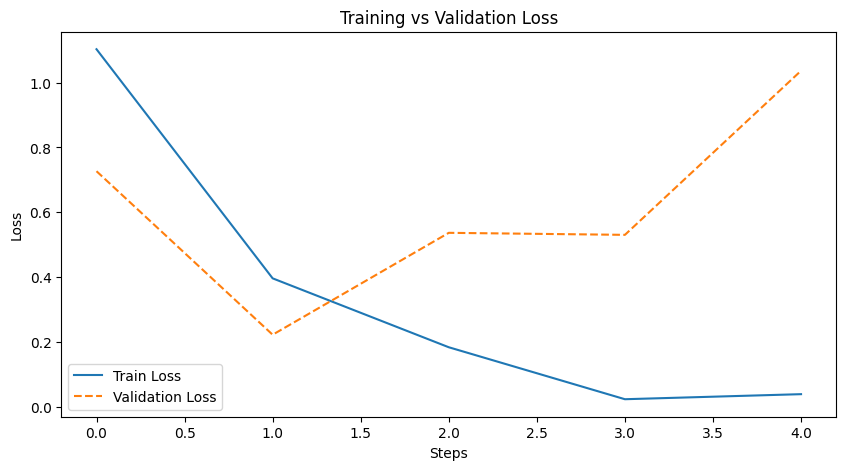

In [ ]:
logs = trainer.state.log_history
train_loss = [x["loss"] for x in logs if "loss" in x]
eval_loss = [x["eval_loss"] for x in logs if "eval_loss" in x]
steps = range(len(train_loss))
plt.figure(figsize=(10, 5))
plt.plot(steps, train_loss, label="Train Loss")
plt.plot(steps, eval_loss, label="Validation Loss", linestyle="dashed")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

In [ ]:
trainer.model.save_pretrained("Sentiment-Adapter-SEQ-CLS")
trainer.processing_class.save_pretrained("Sentiment-Adapter-SEQ-CLS")

('Sentiment-Adapter-SEQ-CLS/tokenizer_config.json',
 'Sentiment-Adapter-SEQ-CLS/special_tokens_map.json',
 'Sentiment-Adapter-SEQ-CLS/tokenizer.json')

In [ ]:
model.load_adapter("Sentiment-Adapter-SEQ-CLS", adapter_name="SeAd-SEQ-CLS")

In [ ]:
model.active_adapters()

['SeAd-SEQ-CLS']

In [ ]:
del peft_model, trainer
gc.collect()
torch.cuda.empty_cache()

In [ ]:
y_after = classify_texts(model, tokenizer, eval_dataset["sentence"], batch_size=25)

Device set to use cuda:0


In [ ]:
print(Counter(y_after))
y_after = [1 if y == "POS" else 0 for y in y_after]

Counter({'POS': 146, 'NEG': 104})


In [ ]:
print(classification_report(eval_dataset["labels"], y_after))

              precision    recall  f1-score   support

           0       0.93      0.91      0.92       107
           1       0.93      0.95      0.94       143

    accuracy                           0.93       250
   macro avg       0.93      0.93      0.93       250
weighted avg       0.93      0.93      0.93       250

